In [1]:
import numpy as np
import random
from matplotlib import pyplot as plt
from itertools import combinations

In [10]:
class BingoCard:
    def __init__(self):
        # Create a random bingo card
        bingoCard = np.zeros((5,5))
        numberDivisions = [1,16,31,45,60]

        for i, start in enumerate(numberDivisions):
            possibleNumbers = np.arange(start, start + 15).tolist()
            bingoCard[:,i] = random.sample(possibleNumbers,5)

        self.card = bingoCard
        self.mask = np.zeros((5,5))
        
    def _checkForWin(self):
        if np.max(np.sum(self.mask, axis=0)) == 5: # Check for a column win
            return True
        elif np.max(np.sum(self.mask, axis=1)) == 5: # Check for a row win
            return True
        elif np.max(np.sum(np.diag(self.mask))) == 5: # Check for a diagonal win (first way)
            return True
        elif np.max(np.sum(np.diag(np.rot90(self.mask)))) == 5: # Check for a diagonal win (second way)
            return True
        else:
            return False
        
        
    def play(self):
        # Reset the mask
        self.mask = np.zeros((5,5))
        callOrder = np.arange(1,76).tolist()
        callOrder = random.sample(callOrder, len(callOrder))
        turns = 0
    
        for calledNumber in callOrder:
            turns += 1
            # Check if the number called is on the card
            if calledNumber in self.card:
                position = self.card == calledNumber
                self.mask += position
            if self._checkForWin():
                return turns
        return turns
    
        
    
    def __str__(self):
            
        result = "***********************BINGO***********************\n\n"
        n = self.card.shape[0]
        for i in range(n):
            for j in range(n):
                if self.mask[i,j] == 1: # Not quite right yet
                    addIt = "\033[1;31;32m" + str(int(self.card[i,j]))
                else:
                    addIt = "\033[0m" + str(int(self.card[i,j]))
                result = result + "\t" + addIt
            result += '\n'
        return result
    
    

In [21]:
from tqdm import tqdm
games: list[float] = []
tiles_filled: list[float] = []

for k in np.arange(2, 6):
    games: list[float] = []
    tiles_filled: list[float] = []
    for i in tqdm(range(10**k)):
        card1 = BingoCard()
        turns = card1.play()
        games.append(turns)
        tiles_filled.append(np.sum(card1.mask))

    print(f"n = {10**k}")
    print(f"Xbar = {np.mean(games)}")
    print(f"Zbar = {np.mean(tiles_filled)}")
    print("\n")
    

100%|██████████| 100/100 [00:00<00:00, 838.75it/s]


n = 100
Xbar = 44.75
Zbar = 15.24




100%|██████████| 1000/1000 [00:01<00:00, 905.59it/s]


n = 1000
Xbar = 43.522
Zbar = 14.916




100%|██████████| 10000/10000 [00:11<00:00, 888.81it/s]


n = 10000
Xbar = 43.7279
Zbar = 14.9337




100%|██████████| 100000/100000 [01:49<00:00, 913.11it/s]

n = 100000
Xbar = 43.55898
Zbar = 14.90944




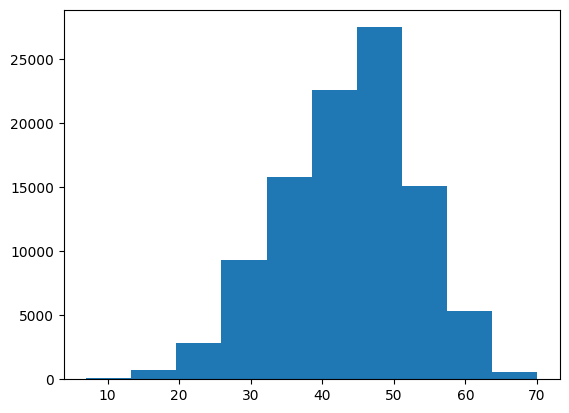

In [4]:
plt.hist(games)
plt.show()

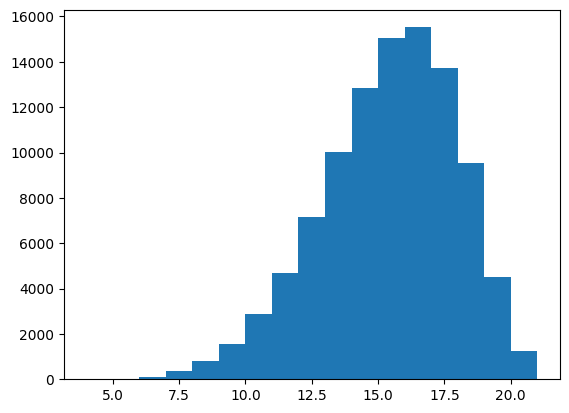

In [5]:
plt.hist(tiles_filled, bins=np.arange(4, 22))
plt.show()

In [6]:
np.min(tiles_filled)

np.float64(5.0)

In [7]:
print(str(card1))

***********************BINGO***********************

	15	18	31	51	63
	6	24	32	54	62
	1	21	45	55	60
	8	26	36	52	65
	14	20	42	46	70



In [8]:
# NOTE: We don't actually need to randomize the bingo card. We could just number them 0-24 or 1-25
k = 12

def checkForWin(mask):
    
    if np.max(np.sum(mask, axis=0)) == 5: # Check for a column win
        return True
    elif np.max(np.sum(mask, axis=1)) == 5: # Check for a row win
        return True
    elif np.max(np.sum(np.diag(mask))) == 5: # Check for a diagonal win (first way)
        return True
    elif np.max(np.sum(np.diag(np.rot90(mask)))) == 5: # Check for a diagonal win (second way)
        return True
    else:
        return False
    
i = 0
total = 0
for tiles in combinations(np.arange(25), k):
    tilesArray = np.array(tiles)
    # Iterate through all possible combinations of tiles

    mask = np.zeros(25)
    mask[tilesArray] = True
    mask = mask.reshape((5,5))

    total += checkForWin(mask)

    if i % 100000 == 0:
        print(i)
        if i != 0:
            break

    i += 1
    
print(f"Total: {total}")

0
100000
Total: 79786


In [9]:
79786

79786